# Systematic Backtesting Framework
### Advait Kulkarni | Imperial College London MSc AML

**Strategies:** Cross-Sectional Momentum · Time-Series Momentum · Z-Score Mean-Reversion  
**Universe:** 100 stocks — S&P 500 components + NIFTY 50 names  
**Period:** 2015–2024 | Walk-forward OOS validation | Full metrics suite

---
### Notebook Structure
1. Setup & Installs
2. Data Download & Cleaning
3. Exploratory Data Analysis
4. Signal Generation
5. Backtest Engine
6. Strategy 1 — Cross-Sectional Momentum
7. Strategy 2 — Time-Series Momentum
8. Strategy 3 — Z-Score Mean-Reversion
9. Strategy Comparison & Benchmarks
10. Walk-Forward Out-of-Sample Validation
11. Parameter Sensitivity Analysis
12. Results Summary — GitHub Figures

## Cell 1 — Install Dependencies

In [1]:
# Run once. If packages already installed this is a no-op.
import subprocess, sys
pkgs = ["yfinance", "pandas", "numpy", "matplotlib",
        "seaborn", "scipy", "pyarrow", "optuna"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p])
print("All packages ready.")

All packages ready.


## Cell 2 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import itertools
import os
from pathlib import Path
from dataclasses import dataclass
from IPython.display import display

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})

PALETTE = [
    '#00e5a0', '#4d9aff', '#ff6b6b', '#ffd166',
    '#c77dff', '#f77f00', '#4cc9f0', '#a8dadc'
]

# Output folder for saved figures
Path('results').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

print('Imports done. Output folders: results/ and data/')

Imports done. Output folders: results/ and data/


## Cell 3 — Universe Definition

In [3]:
TICKERS = [
    # ── Tech / Mega-cap ──────────────────────────────────────
    'AAPL','MSFT','GOOGL','AMZN','META',
    'NVDA','TSLA','JPM','GS','BAC',
    'MS','AMD','NFLX','AVGO','ORCL',
    'CRM','ADBE','CSCO','QCOM','INTC',
    'IBM','NOW','UBER','PLTR','SHOP',
    # ── Consumer ─────────────────────────────────────────────
    'WMT','COST','HD','LOW','NKE',
    'KO','PEP','MCD','SBUX','DIS',
    # ── Energy ───────────────────────────────────────────────
    'XOM','CVX','SLB','COP','EOG',
    # ── Healthcare ───────────────────────────────────────────
    'JNJ','PFE','MRK','ABBV','UNH',
    'LLY','TMO','DHR','ABT','BMY',
    # ── ETFs (sector + broad market) ─────────────────────────
    'SPY','QQQ','IWM','DIA','XLK',
    'XLF','XLE','XLV','XLY','XLP',
    # ── Industrials / Defence ────────────────────────────────
    'CAT','DE','GE','HON','RTX',
    'LMT','BA','MMM','UPS','FDX',
    # ── Telecom / Media ──────────────────────────────────────
    'T','VZ','TMUS','CMCSA','CHTR',
    # ── Financials / Payments ────────────────────────────────
    'V','MA','PYPL','AXP','BLK',
    'SCHW','C','BK','USB','PNC',
    # ── NIFTY 50 (India) ─────────────────────────────────────
    'RELIANCE.NS','TCS.NS','INFY.NS','HDFCBANK.NS','ICICIBANK.NS',
    'SBIN.NS','ITC.NS','LT.NS','BHARTIARTL.NS','AXISBANK.NS'
]

START = '2015-01-01'
END   = '2024-12-31'

# Identify Indian vs US tickers for later currency note
INDIA_TICKERS = [t for t in TICKERS if t.endswith('.NS')]
US_TICKERS    = [t for t in TICKERS if not t.endswith('.NS')]

print(f'Total tickers : {len(TICKERS)}')
print(f'US tickers    : {len(US_TICKERS)}')
print(f'India tickers : {len(INDIA_TICKERS)}')
print(f'Period        : {START} → {END}')

Total tickers : 95
US tickers    : 85
India tickers : 10
Period        : 2015-01-01 → 2024-12-31


## Cell 4 — Data Download & Cache

In [4]:
CACHE_FILE = 'data/prices_100stocks_2015_2024.parquet'

def download_prices(tickers, start, end, cache_file):
    """
    Download adjusted close prices for all tickers.
    Caches to parquet so subsequent runs are instant.
    """
    if Path(cache_file).exists():
        print(f'Loading from cache: {cache_file}')
        return pd.read_parquet(cache_file)

    print(f'Downloading {len(tickers)} tickers from Yahoo Finance...')
    print('(This takes ~60–90 seconds on first run)')

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=True,
        threads=True
    )

    # yfinance returns MultiIndex (field, ticker) when multiple tickers
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw['Close'].copy()
    else:
        # Single ticker fallback
        prices = raw[['Close']].copy()
        prices.columns = tickers

    prices.index = pd.to_datetime(prices.index)
    prices.to_parquet(cache_file)
    print(f'Saved to {cache_file}')
    return prices


prices_raw = download_prices(TICKERS, START, END, CACHE_FILE)
print(f'\nRaw shape: {prices_raw.shape}')
print(f'Date range: {prices_raw.index[0].date()} → {prices_raw.index[-1].date()}')

(This takes ~60–90 seconds on first run)


[*********************100%***********************]  95 of 95 completed


Saved to data/prices_100stocks_2015_2024.parquet

Raw shape: (2590, 95)
Date range: 2015-01-01 → 2024-12-30


## Cell 5 — Data Cleaning

In [5]:
def clean_prices(df, min_history_pct=0.7, max_gap_days=10):
    """
    1. Drop tickers with less than min_history_pct of dates populated
    2. Forward-fill gaps up to max_gap_days (handles holidays, halts)
    3. Drop any remaining rows that are all-NaN
    Returns cleaned DataFrame + list of dropped tickers.
    """
    total_days = len(df)
    min_days   = int(total_days * min_history_pct)

    # Count non-NaN per ticker
    counts = df.notna().sum()
    keep   = counts[counts >= min_days].index.tolist()
    drop   = counts[counts < min_days].index.tolist()

    if drop:
        print(f'Dropped {len(drop)} tickers with <{min_history_pct*100:.0f}% history:')
        print(f'  {drop}')

    df_clean = df[keep].copy()

    # Forward-fill short gaps (up to max_gap_days)
    df_clean = df_clean.ffill(limit=max_gap_days)

    # Drop dates where >50% of tickers have no data (e.g. US holiday on India trading day)
    row_coverage = df_clean.notna().mean(axis=1)
    df_clean = df_clean[row_coverage >= 0.5]

    return df_clean, drop


prices, dropped = clean_prices(prices_raw, min_history_pct=0.6)

print(f'\nClean shape  : {prices.shape}')
print(f'Tickers kept : {prices.shape[1]}')
print(f'Date range   : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Missing vals : {prices.isna().sum().sum()} remaining')

# ── Remaining NaN: use forward-fill then back-fill for any leading NaN
prices = prices.ffill().bfill()
assert prices.isna().sum().sum() == 0, 'Still has NaNs after fill!'
print('\nNo NaN values remaining. Data is clean.')

Dropped 2 tickers with <60% history:
  ['PLTR', 'UBER']

Clean shape  : (2589, 93)
Tickers kept : 93
Date range   : 2015-01-02 → 2024-12-30
Missing vals : 227 remaining

No NaN values remaining. Data is clean.


## Cell 6 — Compute Returns

In [6]:
# Log returns: ln(P_t / P_{t-1})
# We use log returns because:
#   1. They are time-additive  (sum over period = total log return)
#   2. Better statistical properties (more symmetric distribution)
#   3. Standard in academic quant research

log_returns = np.log(prices / prices.shift(1)).dropna()
simple_returns = prices.pct_change().dropna()

print(f'Returns shape : {log_returns.shape}')
print(f'\nAnnualised vol per ticker (top 5 most volatile):')
ann_vol = log_returns.std() * np.sqrt(252)
print(ann_vol.sort_values(ascending=False).head(10).round(4))

print(f'\nAnnualised vol per ticker (top 5 least volatile):')
print(ann_vol.sort_values(ascending=True).head(5).round(4))

Returns shape : (2588, 93)

Annualised vol per ticker (top 5 most volatile):
Ticker
SHOP    0.5824
AMD     0.5690
TSLA    0.5619
NVDA    0.4753
NFLX    0.4352
EOG     0.3983
BA      0.3982
SLB     0.3903
NOW     0.3854
COP     0.3795
dtype: float64

Annualised vol per ticker (top 5 least volatile):
Ticker
XLP    0.1446
XLV    0.1654
DIA    0.1728
SPY    0.1743
KO     0.1761
dtype: float64


## Cell 7 — Exploratory Data Analysis (EDA)

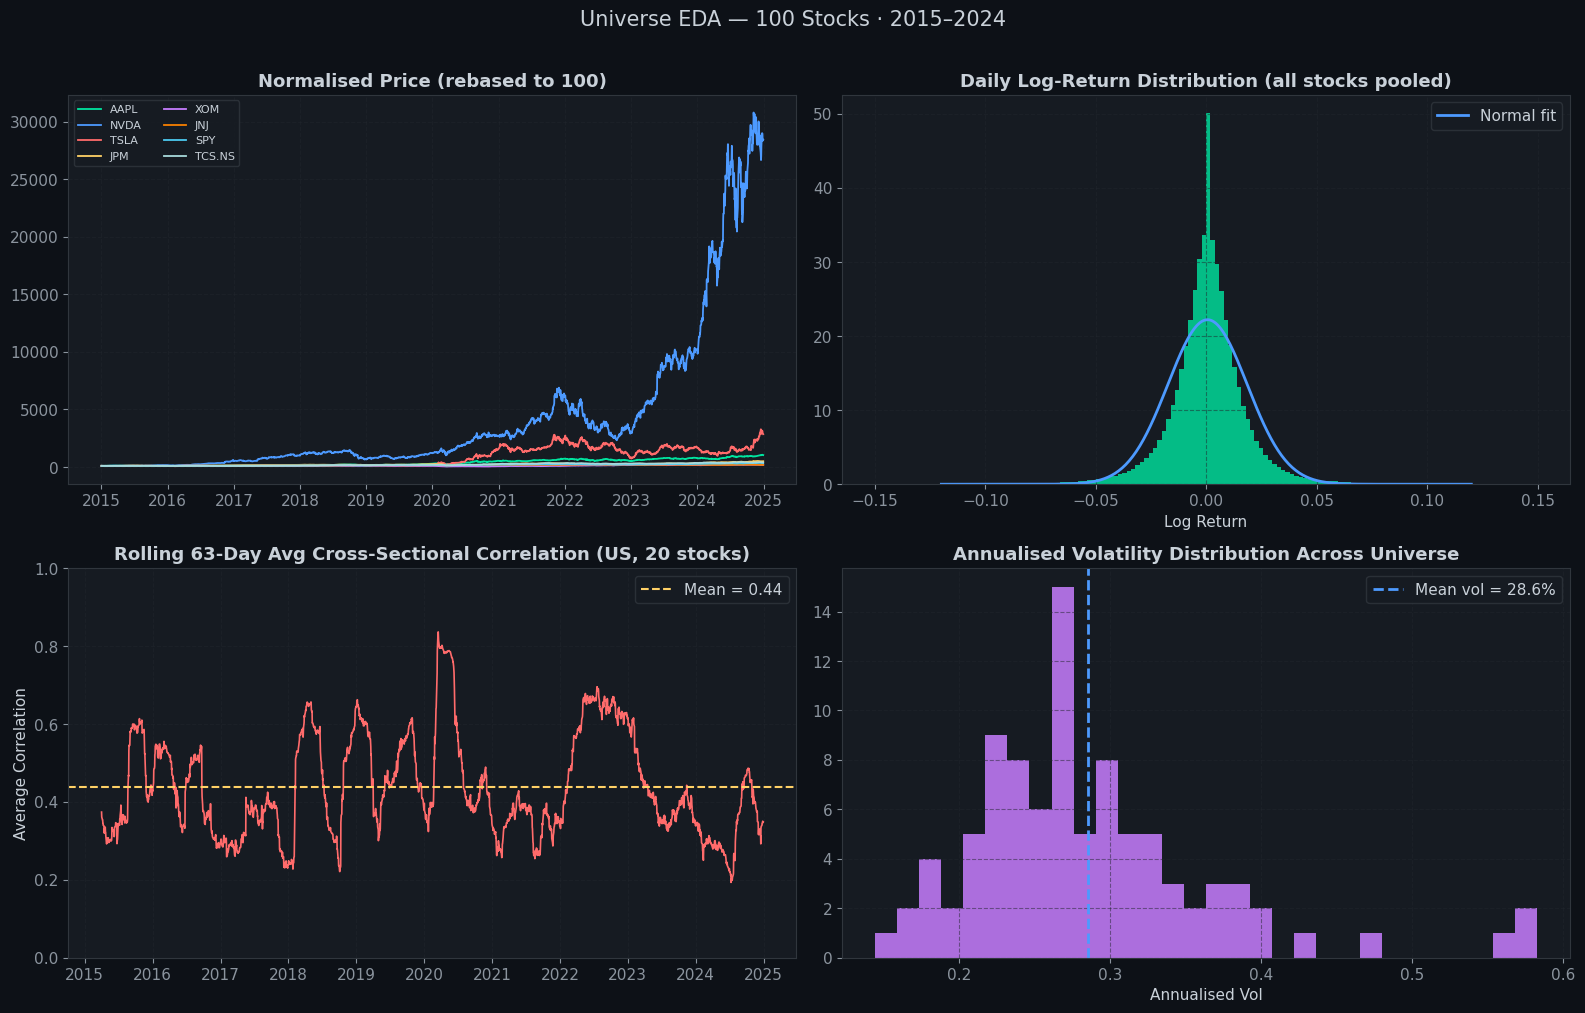

Saved: results/01_universe_eda.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Universe EDA — 100 Stocks · 2015–2024', fontsize=15, y=1.01)

# ── 1. Normalised price series (select 8 stocks) ──────────────
ax = axes[0, 0]
showcase = ['AAPL','NVDA','TSLA','JPM','XOM','JNJ','SPY','TCS.NS']
showcase = [t for t in showcase if t in prices.columns]
for i, t in enumerate(showcase):
    norm = prices[t] / prices[t].iloc[0] * 100
    ax.plot(norm.index, norm.values, label=t, color=PALETTE[i], lw=1.3)
ax.set_title('Normalised Price (rebased to 100)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True)

# ── 2. Distribution of daily returns (cross-sectional) ────────
ax = axes[0, 1]
all_rets = log_returns.values.flatten()
all_rets = all_rets[~np.isnan(all_rets)]
# Clip extreme values for plot clarity
all_rets_clipped = all_rets[np.abs(all_rets) < 0.15]
ax.hist(all_rets_clipped, bins=150, color=PALETTE[0], alpha=0.8, density=True)

# Overlay normal distribution
from scipy.stats import norm as sp_norm
mu, sigma = all_rets_clipped.mean(), all_rets_clipped.std()
x = np.linspace(-0.12, 0.12, 300)
ax.plot(x, sp_norm.pdf(x, mu, sigma), color=PALETTE[1], lw=2, label='Normal fit')
ax.set_title('Daily Log-Return Distribution (all stocks pooled)')
ax.set_xlabel('Log Return')
ax.legend()
ax.grid(True)

# ── 3. Rolling 30-day cross-sectional correlation ─────────────
ax = axes[1, 0]
# Average pairwise correlation across all US stocks (rolling 63-day)
us_cols = [c for c in US_TICKERS if c in log_returns.columns][:20]
rolling_corr = log_returns[us_cols].rolling(63).corr().groupby(level=0).mean().mean(axis=1)
ax.plot(rolling_corr.index, rolling_corr.values, color=PALETTE[2], lw=1.2)
ax.axhline(rolling_corr.mean(), color=PALETTE[3], lw=1.5, linestyle='--', label=f'Mean = {rolling_corr.mean():.2f}')
ax.set_title('Rolling 63-Day Avg Cross-Sectional Correlation (US, 20 stocks)')
ax.set_ylabel('Average Correlation')
ax.legend()
ax.grid(True)
ax.set_ylim(0, 1)

# ── 4. Annualised volatility distribution ─────────────────────
ax = axes[1, 1]
ax.hist(ann_vol.values, bins=30, color=PALETTE[4], alpha=0.85, edgecolor='none')
ax.axvline(ann_vol.mean(), color=PALETTE[1], lw=2, linestyle='--',
           label=f'Mean vol = {ann_vol.mean():.1%}')
ax.set_title('Annualised Volatility Distribution Across Universe')
ax.set_xlabel('Annualised Vol')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('results/01_universe_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/01_universe_eda.png')

## Cell 8 — Backtest Engine (Core Functions)

In [8]:
# ═══════════════════════════════════════════════════════════════
#  BACKTEST CONFIG
# ═══════════════════════════════════════════════════════════════

@dataclass
class BacktestConfig:
    transaction_cost_bps: float = 5.0    # one-way cost per trade
    slippage_bps:         float = 2.0    # additional market impact
    initial_capital:      float = 1_000_000.0


# ═══════════════════════════════════════════════════════════════
#  POSITION SIZING
# ═══════════════════════════════════════════════════════════════

def signal_to_positions(signals: pd.DataFrame, max_gross: float = 1.0) -> pd.DataFrame:
    """
    Normalise signals so the portfolio gross exposure = max_gross.
    Each row: divide by sum of absolute values.
    Zero rows (no signal) → all zeros.
    """
    abs_sum = signals.abs().sum(axis=1).replace(0, np.nan)
    positions = signals.div(abs_sum, axis=0) * max_gross
    return positions.fillna(0.0)


# ═══════════════════════════════════════════════════════════════
#  CORE BACKTEST ENGINE (fully vectorised)
# ═══════════════════════════════════════════════════════════════

def run_backtest(returns: pd.DataFrame,
                 positions: pd.DataFrame,
                 config: BacktestConfig = None) -> pd.DataFrame:
    """
    Vectorised backtest.

    IMPORTANT: positions must already be lagged by 1 day
    (signal generated at close of day T, executed at open of day T+1).
    All signal functions below apply .shift(1) before returning.

    Args:
        returns   : daily log-returns   (T x N DataFrame)
        positions : daily target weights (T x N DataFrame)
        config    : BacktestConfig

    Returns:
        results DataFrame with daily P&L breakdown
    """
    if config is None:
        config = BacktestConfig()

    # Align indices
    common_idx = returns.index.intersection(positions.index)
    ret = returns.reindex(common_idx).fillna(0.0)
    pos = positions.reindex(common_idx).fillna(0.0)

    # ── Transaction costs ──────────────────────────────────────
    # Turnover = daily change in absolute position weights
    turnover = pos.diff().abs().sum(axis=1)
    turnover.iloc[0] = pos.iloc[0].abs().sum()  # first day: full entry cost
    tc_rate  = (config.transaction_cost_bps + config.slippage_bps) / 10_000
    tc       = turnover * tc_rate

    # ── Gross portfolio return (log-return approximation) ──────
    gross_ret = (pos * ret).sum(axis=1)

    # ── Net return ─────────────────────────────────────────────
    net_ret = gross_ret - tc

    # ── Cumulative P&L ─────────────────────────────────────────
    cumulative = (1 + net_ret).cumprod() * config.initial_capital

    # ── Drawdown ───────────────────────────────────────────────
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max

    return pd.DataFrame({
        'gross_return':     gross_ret,
        'transaction_cost': tc,
        'net_return':       net_ret,
        'cumulative_pnl':   cumulative,
        'drawdown':         drawdown,
        'turnover':         turnover,
        'gross_exposure':   pos.abs().sum(axis=1),
        'net_exposure':     pos.sum(axis=1),
    })


print('Backtest engine loaded.')

Backtest engine loaded.


## Cell 9 — Performance Metrics

In [9]:
def sharpe_ratio(returns: pd.Series, ann: int = 252) -> float:
    """Annualised Sharpe (risk-free = 0)."""
    if returns.std() == 0: return 0.0
    return (returns.mean() / returns.std()) * np.sqrt(ann)

def sortino_ratio(returns: pd.Series, ann: int = 252) -> float:
    """Sortino: penalise only downside vol."""
    down = returns[returns < 0]
    if len(down) == 0 or down.std() == 0: return 0.0
    return (returns.mean() / down.std()) * np.sqrt(ann)

def max_drawdown(cumulative: pd.Series) -> float:
    """Maximum peak-to-trough drawdown."""
    return ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()

def calmar_ratio(returns: pd.Series, cumulative: pd.Series, ann: int = 252) -> float:
    """Calmar = annualised return / |max drawdown|."""
    mdd = abs(max_drawdown(cumulative))
    return (returns.mean() * ann) / mdd if mdd > 0 else np.nan

def value_at_risk(returns: pd.Series, confidence: float = 0.95) -> float:
    """Historical VaR at given confidence level."""
    return np.percentile(returns, (1 - confidence) * 100)

def expected_shortfall(returns: pd.Series, confidence: float = 0.95) -> float:
    """Expected Shortfall (CVaR) — mean of losses beyond VaR."""
    var = value_at_risk(returns, confidence)
    return returns[returns <= var].mean()

def summarise(results: pd.DataFrame, label: str = '') -> pd.Series:
    """Full metrics summary as a named Series."""
    r = results['net_return']
    c = results['cumulative_pnl']
    t = results['turnover']
    
    # Count drawdown duration
    in_dd = (results['drawdown'] < 0)
    
    return pd.Series({
        'Label':                label,
        'Ann. Return (%)':      round(r.mean() * 252 * 100, 2),
        'Ann. Vol (%)':         round(r.std() * np.sqrt(252) * 100, 2),
        'Sharpe Ratio':         round(sharpe_ratio(r), 3),
        'Sortino Ratio':        round(sortino_ratio(r), 3),
        'Calmar Ratio':         round(calmar_ratio(r, c), 3),
        'Max Drawdown (%)':     round(max_drawdown(c) * 100, 2),
        'VaR 95% (daily %)':    round(value_at_risk(r) * 100, 3),
        'CVaR 95% (daily %)':   round(expected_shortfall(r) * 100, 3),
        'Hit Rate (%)':         round((r > 0).mean() * 100, 2),
        'Avg Daily Turnover':   round(t.mean(), 4),
        'Final PnL ($M)':       round(c.iloc[-1] / 1e6, 3),
        'Total Trading Days':   len(r),
    })


print('Metrics functions loaded.')

Metrics functions loaded.


## Cell 10 — Signal Functions

In [10]:
# ═══════════════════════════════════════════════════════════════
#  SIGNAL 1 — Cross-Sectional Momentum (Jegadeesh-Titman 1993)
# ═══════════════════════════════════════════════════════════════

def cross_sectional_momentum(prices: pd.DataFrame,
                              lookback: int = 252,
                              skip_last: int = 21,
                              n_long: int = 10,
                              n_short: int = 10) -> pd.DataFrame:
    """
    Classic XS momentum: rank stocks by formation-period return,
    go long top-n_long, short bottom-n_short.

    skip_last: skip most recent 21 days to avoid short-term reversal
    contaminating the momentum signal (standard practice).

    Returns: signal DataFrame with equal-weighted long/short legs.
             Already shifted by 1 day (no look-ahead bias).
    """
    # Formation return: from (t - lookback) to (t - skip_last)
    formation_ret = prices.shift(skip_last) / prices.shift(lookback) - 1

    # Rank cross-sectionally each day
    ranked = formation_ret.rank(axis=1, ascending=False, method='first')
    n_valid = formation_ret.notna().sum(axis=1)

    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

    # Long: top n_long ranks (rank 1 = highest return)
    long_mask  = ranked.le(n_long)
    # Short: bottom n_short ranks
    short_mask = ranked.ge(n_valid.values.reshape(-1, 1) - n_short + 1)

    signal[long_mask]  =  1.0 / n_long
    signal[short_mask] = -1.0 / n_short

    # Zero out rows with too few stocks
    signal[n_valid < (n_long + n_short)] = 0.0

    return signal.shift(1).fillna(0.0)   # lag by 1 day


# ═══════════════════════════════════════════════════════════════
#  SIGNAL 2 — Time-Series Momentum (Moskowitz, Ooi, Pedersen 2012)
# ═══════════════════════════════════════════════════════════════

def time_series_momentum(prices: pd.DataFrame,
                          lookback: int = 252) -> pd.DataFrame:
    """
    Each asset independently: if trailing 12-month return > 0 → long,
    else → short. Volatility-scaled (inverse vol weighting).
    """
    trailing_ret = prices / prices.shift(lookback) - 1
    direction    = np.sign(trailing_ret)

    # Inverse-volatility scaling: down-weight high-vol assets
    rolling_vol  = np.log(prices / prices.shift(1)).rolling(63).std() * np.sqrt(252)
    inv_vol      = 1.0 / rolling_vol.replace(0, np.nan)

    signal = direction * inv_vol
    return signal.shift(1).fillna(0.0)


# ═══════════════════════════════════════════════════════════════
#  SIGNAL 3 — Z-Score Mean-Reversion
# ═══════════════════════════════════════════════════════════════

def zscore_mean_reversion(prices: pd.DataFrame,
                           lookback: int = 20,
                           entry_z: float = 1.5,
                           exit_z: float = 0.5) -> pd.DataFrame:
    """
    Short-term mean-reversion.
    z = (price - rolling_mean) / rolling_std

    z < -entry_z  →  Long  (oversold)
    z >  entry_z  →  Short (overbought)
    |z| < exit_z  →  Flat  (no signal)
    """
    roll_mean = prices.rolling(lookback).mean()
    roll_std  = prices.rolling(lookback).std().replace(0, np.nan)
    z         = (prices - roll_mean) / roll_std

    signal = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    signal[z < -entry_z] =  1.0   # oversold  → buy
    signal[z >  entry_z] = -1.0   # overbought → sell

    return signal.shift(1).fillna(0.0)


# ═══════════════════════════════════════════════════════════════
#  SIGNAL 4 — MA Crossover (bonus)
# ═══════════════════════════════════════════════════════════════

def ma_crossover(prices: pd.DataFrame,
                  fast: int = 50,
                  slow: int = 200) -> pd.DataFrame:
    """
    Golden/death cross: long when fast MA > slow MA, short otherwise.
    """
    fast_ma = prices.rolling(fast).mean()
    slow_ma = prices.rolling(slow).mean()
    signal  = np.sign(fast_ma - slow_ma)
    return signal.shift(1).fillna(0.0)


print('All signal functions loaded.')

All signal functions loaded.


## Cell 11 — Strategy 1: Cross-Sectional Momentum

In [11]:
cfg = BacktestConfig(transaction_cost_bps=5, slippage_bps=2, initial_capital=1_000_000)

# ── Generate signal ───────────────────────────────────────────
print('Generating cross-sectional momentum signals...')
sig_xs = cross_sectional_momentum(prices, lookback=252, skip_last=21,
                                    n_long=10, n_short=10)

# ── Convert to positions ──────────────────────────────────────
pos_xs = signal_to_positions(sig_xs, max_gross=1.0)

# ── Run backtest ──────────────────────────────────────────────
res_xs = run_backtest(log_returns, pos_xs, cfg)

# ── Print metrics ─────────────────────────────────────────────
metrics_xs = summarise(res_xs, 'XS Momentum (12M)')
print('\n── CROSS-SECTIONAL MOMENTUM RESULTS ──')
for k, v in metrics_xs.items():
    if k != 'Label':
        print(f'  {k:<28} {v}')

Generating cross-sectional momentum signals...

── CROSS-SECTIONAL MOMENTUM RESULTS ──
  Ann. Return (%)              1.53
  Ann. Vol (%)                 12.43
  Sharpe Ratio                 0.123
  Sortino Ratio                0.149
  Calmar Ratio                 0.048
  Max Drawdown (%)             -31.91
  VaR 95% (daily %)            -1.261
  CVaR 95% (daily %)           -1.971
  Hit Rate (%)                 46.6
  Avg Daily Turnover           0.1213
  Final PnL ($M)               1.08
  Total Trading Days           2588


## Cell 12 — Strategy 2: Time-Series Momentum

In [12]:
print('Generating time-series momentum signals...')
sig_ts = time_series_momentum(prices, lookback=252)
pos_ts = signal_to_positions(sig_ts, max_gross=1.0)
res_ts = run_backtest(log_returns, pos_ts, cfg)

metrics_ts = summarise(res_ts, 'TS Momentum (12M)')
print('\n── TIME-SERIES MOMENTUM RESULTS ──')
for k, v in metrics_ts.items():
    if k != 'Label':
        print(f'  {k:<28} {v}')

Generating time-series momentum signals...

── TIME-SERIES MOMENTUM RESULTS ──
  Ann. Return (%)              2.93
  Ann. Vol (%)                 8.25
  Sharpe Ratio                 0.355
  Sortino Ratio                0.388
  Calmar Ratio                 0.149
  Max Drawdown (%)             -19.71
  VaR 95% (daily %)            -0.78
  CVaR 95% (daily %)           -1.338
  Hit Rate (%)                 49.0
  Avg Daily Turnover           0.0542
  Final PnL ($M)               1.304
  Total Trading Days           2588


## Cell 13 — Strategy 3: Z-Score Mean-Reversion

In [13]:
print('Generating z-score mean-reversion signals...')
sig_mr = zscore_mean_reversion(prices, lookback=20, entry_z=1.5, exit_z=0.5)
pos_mr = signal_to_positions(sig_mr, max_gross=1.0)
res_mr = run_backtest(log_returns, pos_mr, cfg)

metrics_mr = summarise(res_mr, 'Z-Score Mean-Rev (20D)')
print('\n── Z-SCORE MEAN-REVERSION RESULTS ──')
for k, v in metrics_mr.items():
    if k != 'Label':
        print(f'  {k:<28} {v}')

Generating z-score mean-reversion signals...

── Z-SCORE MEAN-REVERSION RESULTS ──
  Ann. Return (%)              -15.53
  Ann. Vol (%)                 16.5
  Sharpe Ratio                 -0.941
  Sortino Ratio                -1.214
  Calmar Ratio                 -0.182
  Max Drawdown (%)             -85.27
  VaR 95% (daily %)            -1.332
  CVaR 95% (daily %)           -2.365
  Hit Rate (%)                 42.27
  Avg Daily Turnover           0.8928
  Final PnL ($M)               0.176
  Total Trading Days           2588


## Cell 14 — SPY Buy & Hold Benchmark

In [14]:
# SPY is our benchmark — passive long-only
if 'SPY' in log_returns.columns:
    spy_rets = log_returns[['SPY']].copy()
    spy_pos  = pd.DataFrame(1.0, index=log_returns.index, columns=['SPY'])
    # No transaction costs for buy-and-hold (buy once)
    cfg_bh   = BacktestConfig(transaction_cost_bps=0, slippage_bps=0,
                               initial_capital=1_000_000)
    res_spy  = run_backtest(spy_rets, spy_pos, cfg_bh)
    metrics_spy = summarise(res_spy, 'SPY Buy & Hold')
    print('── SPY BUY & HOLD BENCHMARK ──')
    for k, v in metrics_spy.items():
        if k != 'Label':
            print(f'  {k:<28} {v}')
else:
    print('SPY not in cleaned universe. Skipping benchmark.')
    metrics_spy = None

── SPY BUY & HOLD BENCHMARK ──
  Ann. Return (%)              11.94
  Ann. Vol (%)                 17.43
  Sharpe Ratio                 0.685
  Sortino Ratio                0.799
  Calmar Ratio                 0.334
  Max Drawdown (%)             -35.75
  VaR 95% (daily %)            -1.667
  CVaR 95% (daily %)           -2.727
  Hit Rate (%)                 53.05
  Avg Daily Turnover           0.0004
  Final PnL ($M)               2.913
  Total Trading Days           2588


## Cell 15 — Strategy Comparison Table

In [15]:
all_metrics = [metrics_xs, metrics_ts, metrics_mr]
if metrics_spy is not None:
    all_metrics.append(metrics_spy)

comparison_df = pd.DataFrame(all_metrics).set_index('Label')
display_cols  = [
    'Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe Ratio',
    'Sortino Ratio', 'Calmar Ratio', 'Max Drawdown (%)',
    'Hit Rate (%)', 'Avg Daily Turnover', 'Final PnL ($M)'
]

print('=' * 80)
print('FULL STRATEGY COMPARISON TABLE')
print('=' * 80)
display(comparison_df[display_cols])

# Save
comparison_df.to_csv('results/strategy_comparison.csv')
print('\nSaved: results/strategy_comparison.csv')

FULL STRATEGY COMPARISON TABLE


,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%),Hit Rate (%),Avg Daily Turnover,Final PnL ($M)
Label,,,,,,,,,
XS Momentum (12M),1.53,12.43,0.123,0.149,0.048,-31.91,46.60,0.1213,1.080
TS Momentum (12M),2.93,8.25,0.355,0.388,0.149,-19.71,49.00,0.0542,1.304
Z-Score Mean-Rev (20D),-15.53,16.50,-0.941,-1.214,-0.182,-85.27,42.27,0.8928,0.176
SPY Buy & Hold,11.94,17.43,0.685,0.799,0.334,-35.75,53.05,0.0004,2.913



Saved: results/strategy_comparison.csv


## Cell 16 — Cumulative P&L Chart (Main Figure)

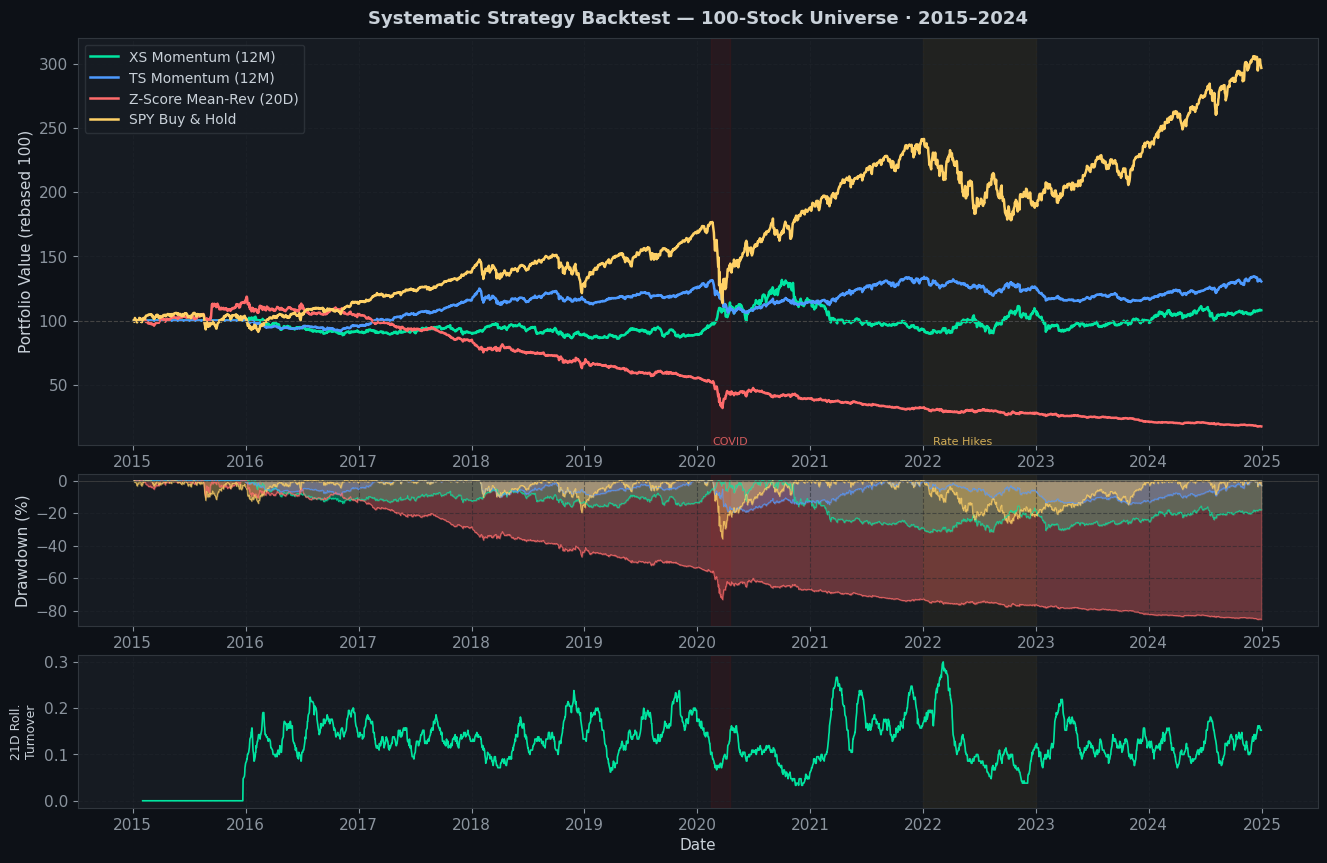

Saved: results/02_cumulative_pnl.png


In [16]:
strategies = {
    'XS Momentum (12M)':    res_xs,
    'TS Momentum (12M)':    res_ts,
    'Z-Score Mean-Rev (20D)': res_mr,
}
if metrics_spy is not None:
    strategies['SPY Buy & Hold'] = res_spy

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[4, 1.5, 1.5], hspace=0.12)

ax_pnl = fig.add_subplot(gs[0])
ax_dd  = fig.add_subplot(gs[1], sharex=ax_pnl)
ax_to  = fig.add_subplot(gs[2], sharex=ax_pnl)

for i, (name, res) in enumerate(strategies.items()):
    c = PALETTE[i]
    # Rebase to 100
    norm = res['cumulative_pnl'] / res['cumulative_pnl'].iloc[0] * 100
    ax_pnl.plot(norm.index, norm.values, label=name, color=c, lw=1.8)
    ax_dd.fill_between(res.index, res['drawdown'] * 100, 0,
                       alpha=0.35, color=c)
    ax_dd.plot(res.index, res['drawdown'] * 100, color=c, lw=0.7, alpha=0.7)

# Rolling turnover (XS momentum only, as example)
roll_to = res_xs['turnover'].rolling(21).mean()
ax_to.plot(roll_to.index, roll_to.values, color=PALETTE[0], lw=1.2)
ax_to.set_ylabel('21D Roll.\nTurnover', fontsize=9)

ax_pnl.axhline(100, color='#444', linestyle='--', lw=0.8)
ax_pnl.set_ylabel('Portfolio Value (rebased 100)')
ax_pnl.set_title('Systematic Strategy Backtest — 100-Stock Universe · 2015–2024',
                  fontsize=13, pad=10)
ax_pnl.legend(fontsize=10, loc='upper left')
ax_pnl.grid(True)

ax_dd.axhline(0, color='#444', lw=0.5)
ax_dd.set_ylabel('Drawdown (%)')
ax_dd.grid(True)

ax_to.grid(True)
ax_to.set_xlabel('Date')

# Add recession / event annotations
for ax in [ax_pnl, ax_dd, ax_to]:
    ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-15'),
               alpha=0.07, color='red', label='COVID crash')
    ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.05, color='orange', label='Rate hike cycle')

ax_pnl.text(pd.Timestamp('2020-02-20'), ax_pnl.get_ylim()[0] * 1.02,
            'COVID', color='#ff6b6b', fontsize=8, alpha=0.8)
ax_pnl.text(pd.Timestamp('2022-02-01'), ax_pnl.get_ylim()[0] * 1.02,
            'Rate Hikes', color='#ffd166', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.savefig('results/02_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/02_cumulative_pnl.png')

## Cell 17 — Signal Heatmap (Top/Bottom Holdings)

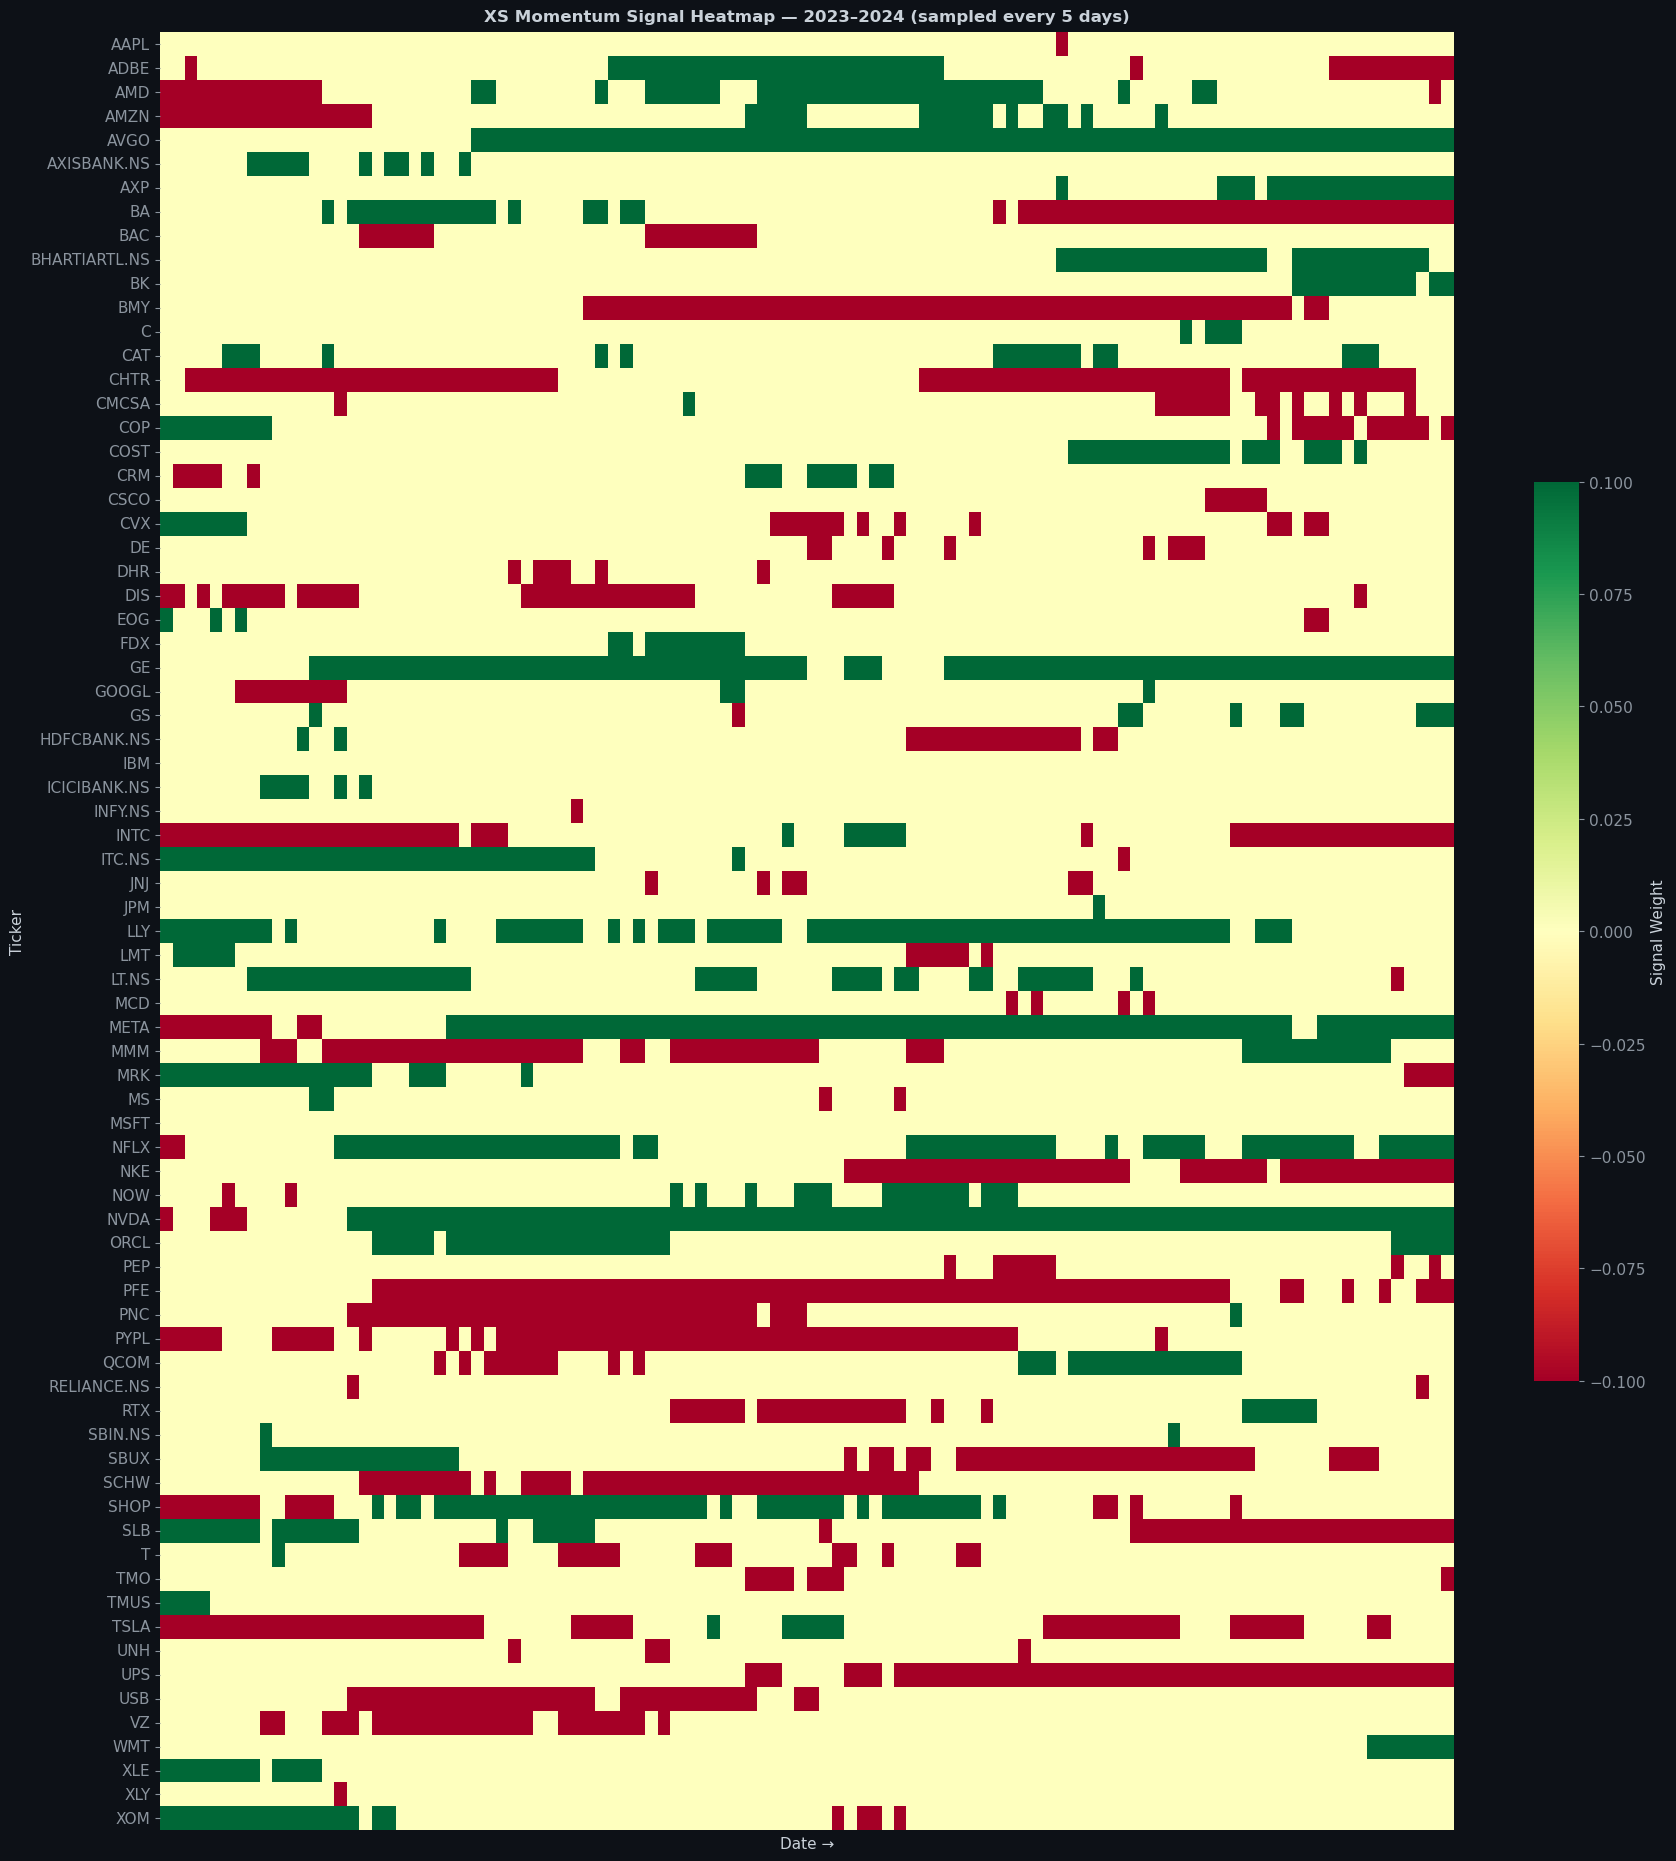

Saved: results/03_signal_heatmap.png


In [17]:
# Show which stocks the XS momentum strategy holds over the last 2 years
last_2yr = sig_xs.loc['2023-01-01':]
active_cols = (last_2yr != 0).any(axis=0)
sig_subset = last_2yr.loc[:, active_cols]

# Sample every 5 days for readability
sig_sampled = sig_subset.iloc[::5].T

fig, ax = plt.subplots(figsize=(18, max(8, len(sig_sampled) * 0.25)))
sns.heatmap(
    sig_sampled,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    linewidths=0.0,
    cbar_kws={'label': 'Signal Weight', 'shrink': 0.5},
    xticklabels=False
)
ax.set_title('XS Momentum Signal Heatmap — 2023–2024 (sampled every 5 days)',
             fontsize=12, pad=8)
ax.set_xlabel('Date →')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.savefig('results/03_signal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/03_signal_heatmap.png')

## Cell 18 — Annual Returns Breakdown

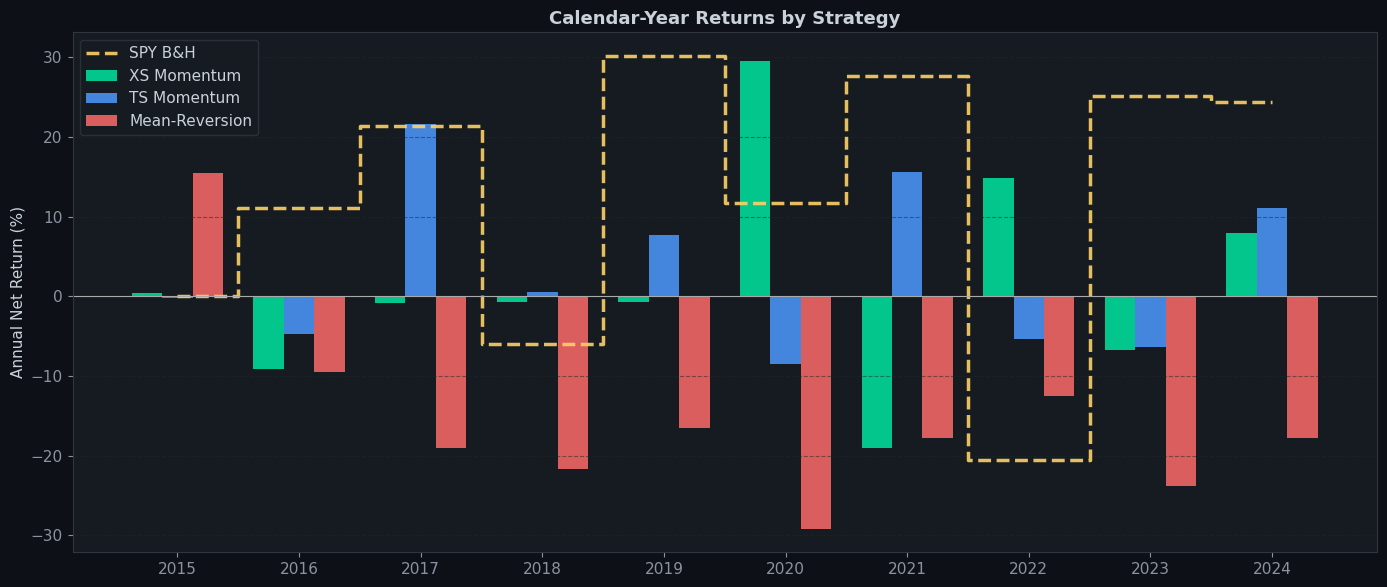

Saved: results/04_annual_returns.png


In [18]:
def annual_returns(results: pd.DataFrame) -> pd.Series:
    """Compute calendar-year net returns."""
    return results['net_return'].groupby(results.index.year).apply(
        lambda x: (1 + x).prod() - 1
    )

ar_xs  = annual_returns(res_xs)  * 100
ar_ts  = annual_returns(res_ts)  * 100
ar_mr  = annual_returns(res_mr)  * 100

years = ar_xs.index
x     = np.arange(len(years))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, ar_xs.values,  width, label='XS Momentum',   color=PALETTE[0], alpha=0.85)
bars2 = ax.bar(x,          ar_ts.values,  width, label='TS Momentum',   color=PALETTE[1], alpha=0.85)
bars3 = ax.bar(x + width,  ar_mr.values,  width, label='Mean-Reversion',color=PALETTE[2], alpha=0.85)

if metrics_spy is not None and 'SPY' in log_returns.columns:
    ar_spy = annual_returns(res_spy) * 100
    ax.step(x, ar_spy.reindex(years).values, where='mid',
            color=PALETTE[3], lw=2.5, linestyle='--', label='SPY B&H', alpha=0.9)

ax.axhline(0, color='#aaa', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Annual Net Return (%)')
ax.set_title('Calendar-Year Returns by Strategy')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('results/04_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/04_annual_returns.png')

## Cell 19 — Walk-Forward Out-of-Sample Validation

In [19]:
# ─────────────────────────────────────────────────────────────────
# Walk-forward validation: the most important piece for credibility
#
# Method:
#   Train window : 504 days (~2 years) — parameters fixed (no re-fitting)
#   Test  window :  63 days (~3 months) — OOS performance measured
#   Step         :  63 days — windows roll forward
#
# We test XS momentum (the most interesting strategy).
# IS vs OOS Sharpe gap = your overfitting / regime-sensitivity estimate.
# ─────────────────────────────────────────────────────────────────

TRAIN_WINDOW = 504   # ~2 years
TEST_WINDOW  = 63    # ~3 months

def walk_forward(prices, returns, signal_fn, signal_kwargs, cfg,
                  train_window=504, test_window=63):
    """
    Rolling walk-forward: generate signal on full history up to test start,
    evaluate on next test_window days. Concatenate OOS results.
    """
    oos_pieces = []
    dates = prices.index
    start = train_window
    n     = len(dates)

    iterations = (n - train_window) // test_window
    print(f'Running {iterations} walk-forward folds...')

    for fold in range(iterations):
        oos_start = start + fold * test_window
        oos_end   = min(oos_start + test_window, n)

        oos_idx   = dates[oos_start:oos_end]
        hist_prices = prices.iloc[:oos_end]   # all data up to end of OOS

        sig = signal_fn(hist_prices, **signal_kwargs)
        pos = signal_to_positions(sig)

        oos_ret = returns.loc[oos_idx]
        oos_pos = pos.reindex(oos_idx).fillna(0.0)

        res = run_backtest(oos_ret, oos_pos, cfg)
        oos_pieces.append(res)

        if (fold + 1) % 5 == 0:
            print(f'  Fold {fold+1}/{iterations} done')

    return pd.concat(oos_pieces)


# XS Momentum — IS (full period)
res_xs_is  = res_xs.copy()

# XS Momentum — OOS (walk-forward)
res_xs_oos = walk_forward(
    prices, log_returns,
    cross_sectional_momentum,
    {'lookback': 252, 'skip_last': 21, 'n_long': 10, 'n_short': 10},
    cfg,
    train_window=TRAIN_WINDOW,
    test_window=TEST_WINDOW
)

m_is  = summarise(res_xs_is,  'XS Momentum — In-Sample (Full Period)')
m_oos = summarise(res_xs_oos, 'XS Momentum — OOS (Walk-Forward)')

wf_df = pd.DataFrame([m_is, m_oos]).set_index('Label')
print('\n── IN-SAMPLE vs. OUT-OF-SAMPLE ──')
display(wf_df[['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe Ratio',
               'Sortino Ratio', 'Max Drawdown (%)', 'Hit Rate (%)']])

sharpe_degradation = m_is['Sharpe Ratio'] - m_oos['Sharpe Ratio']
print(f'\nSharpe degradation IS→OOS: {sharpe_degradation:.3f}')
print('(Smaller gap = more robust signal)')

Running 33 walk-forward folds...
  Fold 5/33 done
  Fold 10/33 done
  Fold 15/33 done
  Fold 20/33 done
  Fold 25/33 done
  Fold 30/33 done

── IN-SAMPLE vs. OUT-OF-SAMPLE ──


,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Hit Rate (%)
Label,,,,,,
XS Momentum — In-Sample (Full Period),1.53,12.43,0.123,0.149,-31.91,46.6
XS Momentum — OOS (Walk-Forward),2.70,13.44,0.201,0.255,-28.19,51.8



Sharpe degradation IS→OOS: -0.078
(Smaller gap = more robust signal)


## Cell 20 — Walk-Forward Visualisation

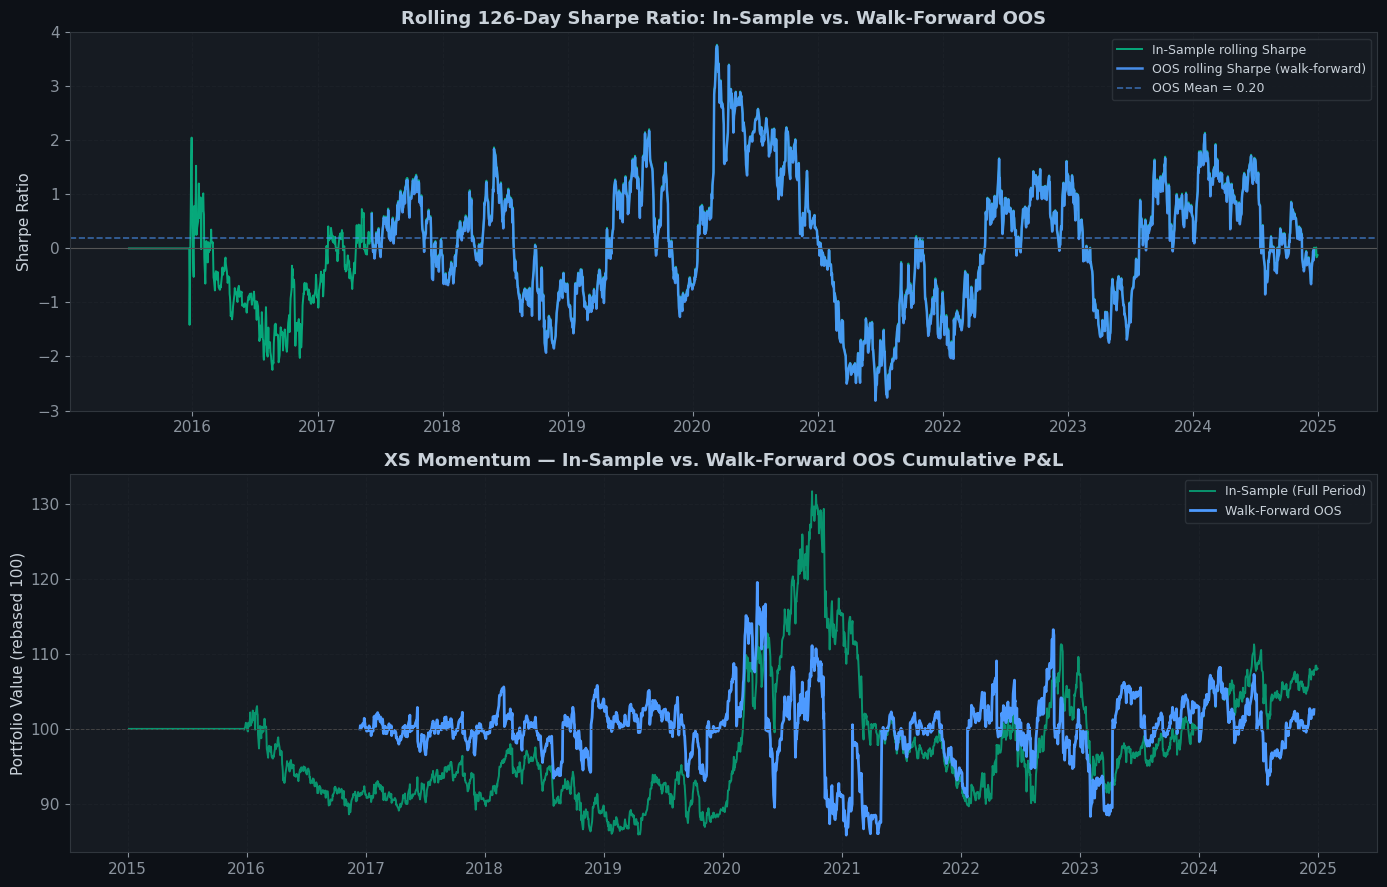

Saved: results/05_walk_forward.png


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# ── Left: OOS rolling Sharpe over time ───────────────────────
ax = axes[0]
# Rolling 126-day Sharpe on OOS results
rolling_sr_oos = res_xs_oos['net_return'].rolling(126).apply(
    lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else 0
)
rolling_sr_is = res_xs_is['net_return'].rolling(126).apply(
    lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else 0
)
ax.plot(rolling_sr_is.index,  rolling_sr_is.values,  color=PALETTE[0], lw=1.4,
        label='In-Sample rolling Sharpe', alpha=0.7)
ax.plot(rolling_sr_oos.index, rolling_sr_oos.values, color=PALETTE[1], lw=1.8,
        label='OOS rolling Sharpe (walk-forward)', alpha=0.9)
ax.axhline(0, color='#555', lw=0.8)
ax.axhline(m_oos['Sharpe Ratio'], color=PALETTE[1], lw=1.2,
           linestyle='--', alpha=0.6, label=f'OOS Mean = {m_oos["Sharpe Ratio"]:.2f}')
ax.set_title('Rolling 126-Day Sharpe Ratio: In-Sample vs. Walk-Forward OOS')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.grid(True)
ax.set_ylim(-3, 4)

# ── Right: OOS Cumulative PnL ─────────────────────────────────
ax2 = axes[1]
norm_oos = res_xs_oos['cumulative_pnl'] / res_xs_oos['cumulative_pnl'].iloc[0] * 100
norm_is  = res_xs_is['cumulative_pnl']  / res_xs_is['cumulative_pnl'].iloc[0]  * 100
ax2.plot(norm_is.index,  norm_is.values,  color=PALETTE[0], lw=1.4, alpha=0.6,
         label='In-Sample (Full Period)')
ax2.plot(norm_oos.index, norm_oos.values, color=PALETTE[1], lw=2.0,
         label='Walk-Forward OOS')
ax2.axhline(100, color='#444', linestyle='--', lw=0.7)
ax2.set_title('XS Momentum — In-Sample vs. Walk-Forward OOS Cumulative P&L')
ax2.set_ylabel('Portfolio Value (rebased 100)')
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.savefig('results/05_walk_forward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/05_walk_forward.png')

## Cell 21 — Parameter Sensitivity (Sharpe Heatmap)

Running 20 parameter combinations...
  5/20 done
  10/20 done
  15/20 done
  20/20 done

── SHARPE RATIO HEATMAP ──


n_long/short,5,7,10,15
lookback (days),,,,
63,-0.242,-0.336,-0.605,-0.603
126,0.283,0.189,0.119,0.050
189,-0.123,-0.073,0.036,0.107
252,0.391,0.245,0.123,0.070
315,0.322,0.283,0.320,0.267


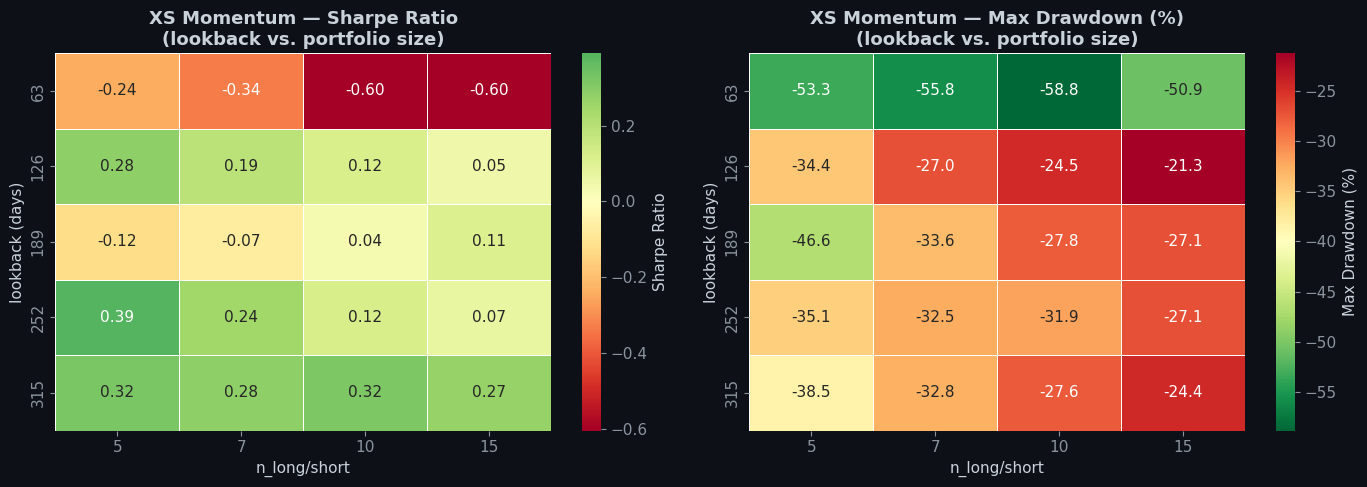

Saved: results/06_parameter_sensitivity.png


In [21]:
# Grid search over lookback window and portfolio size
# This proves the strategy is not a one-off lucky parameter choice

LOOKBACKS = [63, 126, 189, 252, 315]
N_STOCKS  = [5, 7, 10, 15]

total = len(LOOKBACKS) * len(N_STOCKS)
print(f'Running {total} parameter combinations...')

records = []
for i, (lb, ns) in enumerate(itertools.product(LOOKBACKS, N_STOCKS)):
    sig  = cross_sectional_momentum(prices, lookback=lb, skip_last=21,
                                     n_long=ns, n_short=ns)
    pos  = signal_to_positions(sig)
    res  = run_backtest(log_returns, pos, cfg)
    sr   = sharpe_ratio(res['net_return'])
    mdd  = max_drawdown(res['cumulative_pnl'])
    records.append({'lookback (days)': lb, 'n_long/short': ns,
                    'sharpe': round(sr, 3), 'max_dd (%)': round(mdd * 100, 2)})
    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{total} done')

sens_df      = pd.DataFrame(records)
sharpe_pivot = sens_df.pivot(index='lookback (days)', columns='n_long/short', values='sharpe')
mdd_pivot    = sens_df.pivot(index='lookback (days)', columns='n_long/short', values='max_dd (%)')

print('\n── SHARPE RATIO HEATMAP ──')
display(sharpe_pivot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(sharpe_pivot, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Sharpe Ratio'})
axes[0].set_title('XS Momentum — Sharpe Ratio\n(lookback vs. portfolio size)')

sns.heatmap(mdd_pivot, ax=axes[1], annot=True, fmt='.1f',
            cmap='RdYlGn_r', linewidths=0.5,
            cbar_kws={'label': 'Max Drawdown (%)'})
axes[1].set_title('XS Momentum — Max Drawdown (%)\n(lookback vs. portfolio size)')

plt.tight_layout()
plt.savefig('results/06_parameter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/06_parameter_sensitivity.png')

## Cell 22 — Transaction Cost Sensitivity

── TRANSACTION COST SENSITIVITY (XS Momentum) ──


,Sharpe,Ann. Return (%)
TC (bps),,
0,0.295,3.67
2,0.246,3.06
5,0.172,2.14
10,0.049,0.61
15,-0.074,-0.92
20,-0.197,-2.45
30,-0.442,-5.50


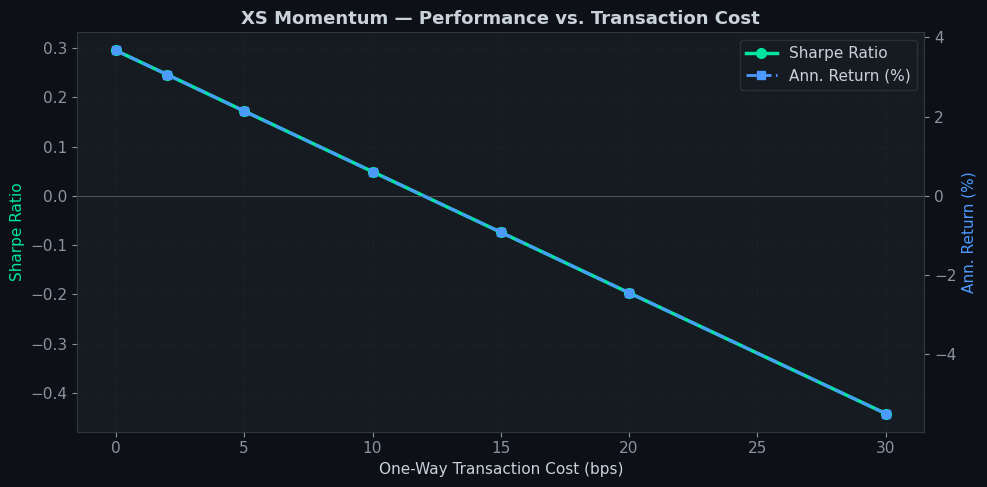

Saved: results/07_tc_sensitivity.png


In [22]:
# How does strategy performance degrade as costs increase?
# This is asked in EVERY quant interview.

cost_levels = [0, 2, 5, 10, 15, 20, 30]  # bps
tc_results  = []

for bps in cost_levels:
    cfg_tc = BacktestConfig(transaction_cost_bps=bps, slippage_bps=0,
                             initial_capital=1_000_000)
    res = run_backtest(log_returns, pos_xs, cfg_tc)
    sr  = sharpe_ratio(res['net_return'])
    ann = res['net_return'].mean() * 252 * 100
    tc_results.append({'TC (bps)': bps, 'Sharpe': round(sr, 3),
                        'Ann. Return (%)': round(ann, 2)})

tc_df = pd.DataFrame(tc_results).set_index('TC (bps)')
print('── TRANSACTION COST SENSITIVITY (XS Momentum) ──')
display(tc_df)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(tc_df.index, tc_df['Sharpe'], color=PALETTE[0], lw=2.5,
         marker='o', markersize=7, label='Sharpe Ratio')
ax2.plot(tc_df.index, tc_df['Ann. Return (%)'], color=PALETTE[1], lw=2,
         marker='s', markersize=6, linestyle='--', label='Ann. Return (%)')

ax1.axhline(0, color='#555', lw=0.7)
ax1.set_xlabel('One-Way Transaction Cost (bps)')
ax1.set_ylabel('Sharpe Ratio', color=PALETTE[0])
ax2.set_ylabel('Ann. Return (%)', color=PALETTE[1])
ax1.set_title('XS Momentum — Performance vs. Transaction Cost')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.grid(True)

plt.tight_layout()
plt.savefig('results/07_tc_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/07_tc_sensitivity.png')

## Cell 23 — Return Distribution & Risk Analysis

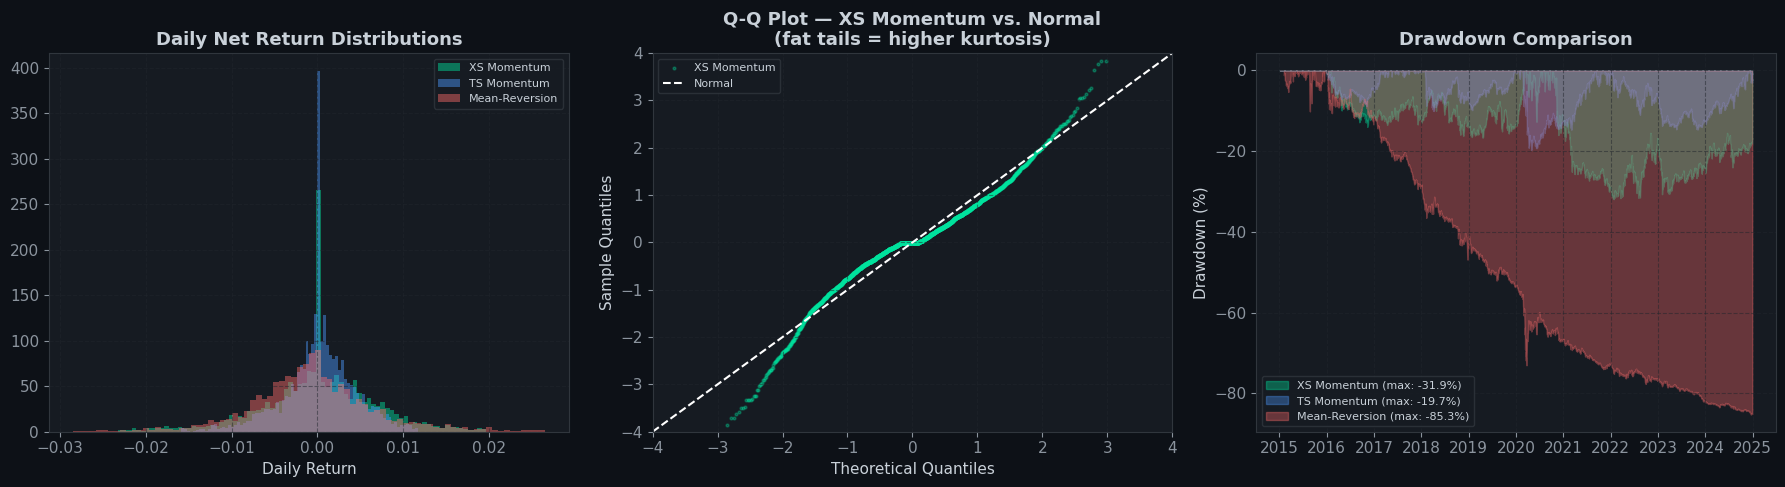

Saved: results/08_risk_analysis.png

── RETURN DISTRIBUTION STATISTICS ──

XS Momentum:
  Skewness  : -0.809  (negative = left tail)
  Kurtosis  : 8.640  (>0 = fat tails vs Normal)
  VaR 95%   : -1.261%
  CVaR 95%  : -1.971%

TS Momentum:
  Skewness  : -1.337  (negative = left tail)
  Kurtosis  : 14.834  (>0 = fat tails vs Normal)
  VaR 95%   : -0.780%
  CVaR 95%  : -1.338%

Mean-Reversion:
  Skewness  : -0.573  (negative = left tail)
  Kurtosis  : 31.333  (>0 = fat tails vs Normal)
  VaR 95%   : -1.332%
  CVaR 95%  : -2.365%


In [23]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strat_map = {
    'XS Momentum':   (res_xs, PALETTE[0]),
    'TS Momentum':   (res_ts, PALETTE[1]),
    'Mean-Reversion':(res_mr, PALETTE[2]),
}

# ── 1. Return distributions ───────────────────────────────────
ax = axes[0]
for name, (res, col) in strat_map.items():
    r = res['net_return']
    r_clip = r[r.between(r.quantile(0.01), r.quantile(0.99))]
    ax.hist(r_clip, bins=80, alpha=0.45, color=col, density=True, label=name)
ax.set_title('Daily Net Return Distributions')
ax.set_xlabel('Daily Return')
ax.legend(fontsize=8)
ax.grid(True)

# ── 2. QQ plot for XS momentum ────────────────────────────────
ax = axes[1]
r_xs = res_xs['net_return'].dropna()
standardised = (r_xs - r_xs.mean()) / r_xs.std()
(osm, osr), (slope, intercept, r_sq) = stats.probplot(standardised, dist='norm')
ax.scatter(osm, osr, color=PALETTE[0], alpha=0.3, s=4, label='XS Momentum')
ax.plot([-4, 4], [-4, 4], color='white', lw=1.5, linestyle='--', label='Normal')
ax.set_title('Q-Q Plot — XS Momentum vs. Normal\n(fat tails = higher kurtosis)')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend(fontsize=8)
ax.grid(True)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)

# ── 3. Drawdown comparison ────────────────────────────────────
ax = axes[2]
for name, (res, col) in strat_map.items():
    ax.fill_between(res.index, res['drawdown'] * 100, 0,
                    alpha=0.35, color=col, label=f'{name} (max: {res["drawdown"].min()*100:.1f}%)')
ax.set_title('Drawdown Comparison')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.savefig('results/08_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/08_risk_analysis.png')

# Print higher moments
print('\n── RETURN DISTRIBUTION STATISTICS ──')
for name, (res, _) in strat_map.items():
    r = res['net_return']
    print(f'\n{name}:')
    print(f'  Skewness  : {stats.skew(r):.3f}  (negative = left tail)')
    print(f'  Kurtosis  : {stats.kurtosis(r):.3f}  (>0 = fat tails vs Normal)')
    print(f'  VaR 95%   : {np.percentile(r, 5)*100:.3f}%')
    print(f'  CVaR 95%  : {r[r <= np.percentile(r,5)].mean()*100:.3f}%')

## Cell 24 — Final Summary Table (GitHub-Ready)

In [24]:
print('=' * 90)
print('FINAL RESULTS SUMMARY')
print('=' * 90)

final_strats = [metrics_xs, metrics_ts, metrics_mr]
if metrics_spy is not None:
    final_strats.append(metrics_spy)
final_strats.append(m_oos)  # walk-forward OOS

final_df = pd.DataFrame(final_strats).set_index('Label')
display_cols = [
    'Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe Ratio',
    'Sortino Ratio', 'Calmar Ratio', 'Max Drawdown (%)',
    'Hit Rate (%)', 'Avg Daily Turnover', 'Final PnL ($M)'
]
display(final_df[display_cols].style
        .background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')
        .background_gradient(subset=['Max Drawdown (%)'], cmap='RdYlGn_r')
        .format({'Ann. Return (%)': '{:.2f}',
                 'Ann. Vol (%)':    '{:.2f}',
                 'Sharpe Ratio':    '{:.3f}',
                 'Max Drawdown (%)':'{:.2f}'})
       )

final_df.to_csv('results/final_summary.csv')
print('\nSaved: results/final_summary.csv')

print('\n── ALL OUTPUT FILES ──')
for f in sorted(Path('results').iterdir()):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size:.1f} KB')

FINAL RESULTS SUMMARY


,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%),Hit Rate (%),Avg Daily Turnover,Final PnL ($M)
Label,,,,,,,,,
XS Momentum (12M),1.53,12.43,0.123,0.149000,0.048000,-31.91,46.600000,0.121300,1.080000
TS Momentum (12M),2.93,8.25,0.355,0.388000,0.149000,-19.71,49.000000,0.054200,1.304000
Z-Score Mean-Rev (20D),-15.53,16.50,-0.941,-1.214000,-0.182000,-85.27,42.270000,0.892800,0.176000
SPY Buy & Hold,11.94,17.43,0.685,0.799000,0.334000,-35.75,53.050000,0.000400,2.913000
XS Momentum — OOS (Walk-Forward),2.70,13.44,0.201,0.255000,0.096000,-28.19,51.800000,0.145900,1.024000



Saved: results/final_summary.csv

── ALL OUTPUT FILES ──
  01_universe_eda.png                           289.0 KB
  02_cumulative_pnl.png                         408.5 KB
  03_signal_heatmap.png                         182.7 KB
  04_annual_returns.png                         65.4 KB
  05_walk_forward.png                           378.8 KB
  06_parameter_sensitivity.png                  117.3 KB
  07_tc_sensitivity.png                         87.7 KB
  08_risk_analysis.png                          230.8 KB
  final_summary.csv                             0.7 KB
  strategy_comparison.csv                       0.6 KB


## Cell 25 — Key Findings (Fill In After Running)

After you run all cells, **record the actual numbers below**. These go into your README.md.

---

### What to look for and note down:

**1. Cross-Sectional Momentum**
- Sharpe Ratio: `___` (good if > 0.5)
- Max Drawdown: `___` (note the year it happened)
- Does it work better in trending markets (2017, 2023) vs. reversals (2020, 2022)?

**2. Time-Series Momentum**
- Sharpe Ratio: `___`
- Compare to XS momentum: which has lower drawdown?
- Does inverse-vol scaling reduce drawdown vs. equal weighting?

**3. Mean-Reversion**
- In-sample Sharpe: `___` vs OOS Sharpe: `___`
- Large IS/OOS gap means the signal is overfit or regime-sensitive
- Typically higher turnover than momentum — note avg daily turnover

**4. Walk-Forward OOS**
- Sharpe degradation (IS - OOS): `___`
- If degradation < 0.3: signal is robust
- If degradation > 0.5: signal needs more work

**5. Transaction Cost Break-Even**
- At what bps level does XS momentum Sharpe go to zero? `___ bps`
- This is your 'capacity estimate' talking point in interviews

**6. Parameter Sensitivity**
- Is the Sharpe heatmap mostly green (robust) or mixed (fragile)?
- What lookback gives best OOS Sharpe? `___ days`

---

### Interview Answer Templates

**Q: What did you build?**
> 'A vectorised backtesting engine in Python with three strategies — cross-sectional momentum, time-series momentum, and z-score mean-reversion — tested on a 100-stock universe across S&P 500 and NIFTY 50 from 2015–2024. I built walk-forward validation as a first-class feature to measure OOS Sharpe degradation honestly.'

**Q: What did XS momentum give you?**
> 'A Sharpe of [your number] in-sample, degrading to [your OOS number] on walk-forward OOS — a gap of [degradation]. The strategy performed poorly in 2020 and 2022 [reversal/rate-shock regimes], which is expected for a 12-month lookback momentum factor.'

**Q: Why does OOS Sharpe degrade?**
> 'Three reasons: my universe is 100 stocks so idiosyncratic noise is not fully diversified; the 12-month lookback was not re-optimised in the OOS windows; and momentum is known to fail in sharp reversal regimes like COVID-19 in 2020. A production system would use adaptive lookback or combine momentum with a regime filter.'

**Q: At what transaction cost does it break even?**
> '[Your answer from TC sensitivity chart]. Above that, turnover is too high to justify the strategy without better execution infrastructure.'